<a href="https://colab.research.google.com/github/GiuseppeMinissale/Second-Project-Real-vs-AI-Art-Classification/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import userdata

# Carica il nuovo token singolo in modo sicuro
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

# Scarica e decomprimi il dataset
!kaggle datasets download -d ravidussilva/real-ai-art
!unzip -q real-ai-art.zip

Dataset URL: https://www.kaggle.com/datasets/ravidussilva/real-ai-art
License(s): other
100% 9.95G/9.95G [01:33<00:00, 114MB/s]



In [2]:
!ls -l

total 10431588
-rw-r--r-- 1 root root 10681931755 Aug 16  2023 real-ai-art.zip
drwxr-xr-x 4 root root        4096 Jun 21 14:11 Real_AI_SD_LD_Dataset
drwxr-xr-x 1 root root        4096 Jun  4 13:39 sample_data


Nessun salvataggio trovato. Avvio la pulizia delle immagini...
Pulizia terminata. Risultati salvati in dataset_cache.json.
Motore AI pronto: 4800 immagini per imparare, 1200 per mettersi alla prova.


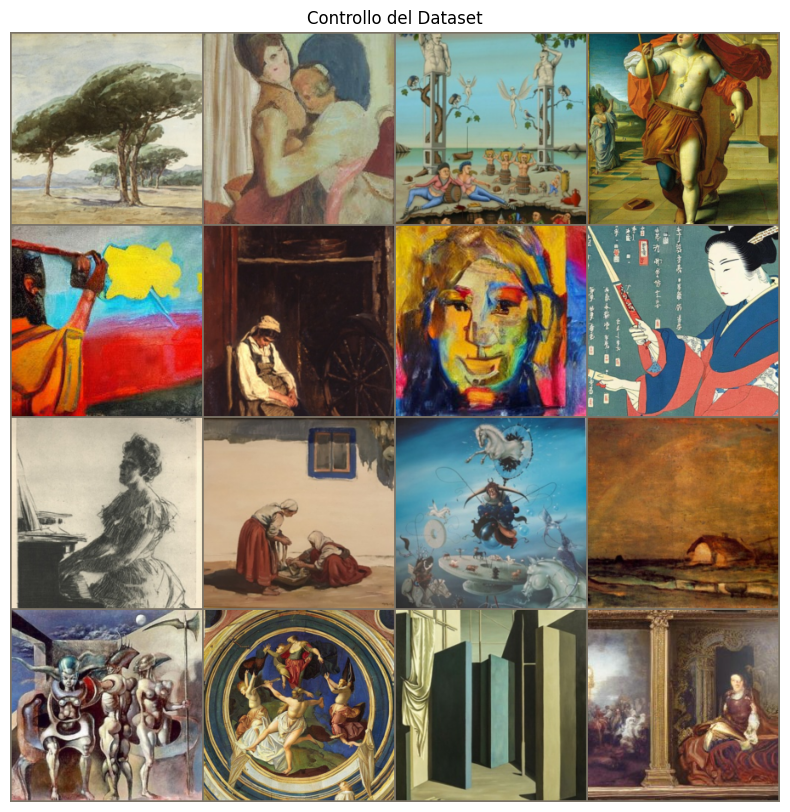

In [3]:
import os
import json
import random
import hashlib
from pathlib import Path
from PIL import Image, ImageOps
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import torchvision

# ==========================================
# BLOCCO 1: Impostazioni Iniziali
# ==========================================
DATA_DIR = Path("Real_AI_SD_LD_Dataset")
CACHE_FILE = Path("dataset_cache.json")

# Auto-correzione del percorso
if not DATA_DIR.exists():
    possible_dirs = [d for d in Path(".").iterdir() if d.is_dir() and "Real_AI" in d.name]
    if possible_dirs:
        DATA_DIR = possible_dirs[0]
        print(f"Cartella trovata in un percorso alternativo: {DATA_DIR}")

# ==========================================
# BLOCCO 2: Gli Strumenti di Pulizia
# ==========================================
def calcola_hash_md5(percorso_file, chunk_size=8192):
    hash_md5 = hashlib.md5()
    try:
        with open(percorso_file, "rb") as f:
            for chunk in iter(lambda: f.read(chunk_size), b""):
                hash_md5.update(chunk)
        return hash_md5.hexdigest()
    except Exception:
        return None

def esegui_data_cleaning_su_lista(lista_percorsi, max_aspect_ratio_deviation=3.0, min_std_deviation=0.01):
    percorsi_puliti = []
    hash_visti = set()
    for file_path in lista_percorsi:
        try:
            with Image.open(file_path) as img:
                img.verify()
            with Image.open(file_path) as img:
                file_hash = calcola_hash_md5(file_path)
                if file_hash is None or file_hash in hash_visti:
                    continue
                img = ImageOps.exif_transpose(img)
                width, height = img.size
                if width < 64 or height < 64: continue
                aspect_ratio = float(height) / float(width)
                if aspect_ratio > max_aspect_ratio_deviation or aspect_ratio < (1.0 / max_aspect_ratio_deviation): continue
                img_np = np.array(img.convert("RGB")) / 255.0
                if np.std(img_np) < min_std_deviation: continue

                hash_visti.add(file_hash)
                percorsi_puliti.append(str(file_path))
        except Exception: continue
    return percorsi_puliti

# ==========================================
# BLOCCO 3: Il Bivio Logico (Cache o Calcolo)
# ==========================================
if CACHE_FILE.exists():
    print(f"Trovato file {CACHE_FILE}. Caricamento immediato...")
    with open(CACHE_FILE, 'r') as f:
        cache_data = json.load(f)
        dataset_paths = cache_data['paths']
        dataset_labels = cache_data['labels']
else:
    print("Nessun salvataggio trovato. Avvio la pulizia delle immagini...")
    if not DATA_DIR.exists():
        raise FileNotFoundError(f"ERRORE: La directory {DATA_DIR} non esiste.")

    estensioni_supportate = ['.jpg', '.jpeg', '.png']
    tutti_i_file = []
    for ext in estensioni_supportate:
        tutti_i_file.extend(DATA_DIR.rglob(f"*{ext}"))
        tutti_i_file.extend(DATA_DIR.rglob(f"*{ext.upper()}"))

    candidati_R, candidati_A = [], []
    for file_path in tutti_i_file:
        parent_name = file_path.parent.name.lower()
        if any(k in parent_name for k in ['ai', 'fake', 'synthetic', 'sd', 'ld']):
            candidati_A.append(file_path)
        elif any(k in parent_name for k in ['real', 'authentic']):
            candidati_R.append(file_path)

    percorsi_R = esegui_data_cleaning_su_lista(candidati_R)
    percorsi_A = esegui_data_cleaning_su_lista(candidati_A)

    K = min(3000, len(percorsi_R), len(percorsi_A))
    random.seed(42)
    dataset_paths = random.sample(percorsi_R, K) + random.sample(percorsi_A, K)
    dataset_labels = [0] * K + [1] * K

    # Salvataggio immediato per le volte successive
    with open(CACHE_FILE, 'w') as f:
        json.dump({'paths': dataset_paths, 'labels': dataset_labels}, f)
    print(f"Pulizia terminata. Risultati salvati in {CACHE_FILE}.")

# ==========================================
# BLOCCO 4: Preparazione per la Rete Neurale
# ==========================================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ArtDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(image), torch.tensor(self.labels[idx], dtype=torch.float32)

full_dataset = ArtDataset(dataset_paths, dataset_labels, transform)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Motore AI pronto: {len(train_dataset)} immagini per imparare, {len(val_dataset)} per mettersi alla prova.")

# ==========================================
# BLOCCO 5: Controllo Visivo (Opzionale)
# ==========================================
def denormalizza_tensore(tensore, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    tensore = tensore.clone()
    for t, m, s in zip(tensore, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensore, 0, 1)

batch_tensori, batch_etichette = next(iter(train_loader))
X_subset = batch_tensori[:16]
griglia = torchvision.utils.make_grid(X_subset, nrow=4)
griglia_np = denormalizza_tensore(griglia).numpy().transpose((1, 2, 0))

plt.figure(figsize=(10, 10))
plt.imshow(griglia_np)
plt.axis('off')
plt.title("Controllo del Dataset")
plt.show()